Install packages

In [1]:
!pip install -q pandas hestia-good seaborn rdkit scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Query HCRTR1 data from ChEMBL

In [ ]:
!curl -L -o chembl_36_sqlite.tar.gz https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz
!tar -xzf chembl_36_sqlite.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5351M  100 5351M    0     0  16.2M      0  0:05:29  0:05:29 --:--:-- 14.0M


In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')
query = """
SELECT cs.canonical_smiles, act.pchembl_value, act.standard_type
FROM activities act
JOIN assays a ON act.assay_id = a.assay_id
JOIN target_dictionary td ON a.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.chembl_id = 'CHEMBL5113'
  AND act.pchembl_value IS NOT NULL
  AND act.standard_relation = '='
"""
df_raw = pd.read_sql_query(query, conn)
print(df_raw.shape)
df_raw.head()

(10368, 3)


,canonical_smiles,pchembl_value,standard_type
0,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,4.18,Ki
1,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,7.89,Ki
2,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,6.57,Ki
3,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccc(Br)cc1)C(C)(C)...,5.16,IC50
4,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccccc1)NC(=O)c1cc(...,5.28,IC50


Clean and deduplicate

In [3]:
df_clean = df_raw.groupby('canonical_smiles')['pchembl_value'].median().reset_index()
df_clean = df_clean[df_clean['pchembl_value'] >= 5].reset_index(drop=True)
print(df_clean.shape)
df_clean.head()

(7090, 2)


,canonical_smiles,pchembl_value
0,C#CC1(c2ccccc2C(=O)N2C[C@H](Oc3nccn4c(C(F)F)cn...,5.750
1,C#Cc1cc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4)C...,5.000
2,C#Cc1cccc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4...,5.000
3,C#Cc1ccnc(O[C@@H]2CC[C@@H](C)N(C(=O)c3ccccc3-n...,6.965
4,C=C1CC(c2nc3c(Br)cccc3[nH]2)N(C(=O)c2cc(C)sc2-...,8.300


Prepare dataframe

In [4]:
df = df_clean[['canonical_smiles', 'pchembl_value']].copy()
df = df.rename(columns={'canonical_smiles': 'Drug', 'pchembl_value': 'Y'})
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(7090, 2)


,Drug,Y
0,C#CC1(c2ccccc2C(=O)N2C[C@H](Oc3nccn4c(C(F)F)cn...,5.750
1,C#Cc1cc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4)C...,5.000
2,C#Cc1cccc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4...,5.000
3,C#Cc1ccnc(O[C@@H]2CC[C@@H](C)N(C(=O)c3ccccc3-n...,6.965
4,C=C1CC(c2nc3c(Br)cccc3[nH]2)N(C(=O)c2cc(C)sc2-...,8.300


Generate Morgan fingerprints

In [5]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    fps = []
    valid_idx = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            fps.append(np.array(fp))
            valid_idx.append(i)
        else:
            fps.append(np.zeros(n_bits))
            valid_idx.append(i)
    return np.array(fps)

X = smiles_to_morgan(df['Drug'].tolist())
y = df['Y'].values
print(f'Fingerprint matrix: {X.shape}')

Fingerprint matrix: (7090, 2048)


Scaffold-based split (same as CLM notebooks)

In [6]:
from hestia.partition import ccpart, random_partition
from hestia.similarity import molecular_similarity

sim_df = molecular_similarity(
    df_query=df,
    fingerprint='ecfp',
    radius=2,
    bits=2048,
    df=df,
    field_name='Drug',
    verbose=3
)

train_idx, test_idx, clusters = ccpart(
    df=df,
    sim_df=sim_df,
    test_size=0.2,
    threshold=0.4,
)

X_train_scaffold, y_train_scaffold = X[train_idx], y[train_idx]
X_test_scaffold,  y_test_scaffold  = X[test_idx],  y[test_idx]
print(f'Train: {len(train_idx):,} | Test: {len(test_idx):,}')

Calculating molecular similarities using ecfp with 2,048 bits, radius 2 and tanimoto index...


Query FPs: 100%|██████████| 7.09k/7.09k [00:00<00:00, 17.7kit/s]
Similarity calculation: 100%|██████████| 7.09k/7.09k [00:20<00:00, 338it/s]


Train: 6,379 | Test: 711


Random 80/20 split

In [7]:
from sklearn.model_selection import train_test_split

X_train_rnd, X_test_rnd, y_train_rnd, y_test_rnd = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Random split -- Train: {len(X_train_rnd):,} | Test: {len(X_test_rnd):,}')

Random split -- Train: 5,672 | Test: 1,418


Train models: Ridge regression and Random Forest

In [8]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

def evaluate(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r, _ = pearsonr(y_te, preds)
    rmse = mean_squared_error(y_te, preds) ** 0.5
    print(f'{label}: Pearson R = {r:.3f}, RMSE = {rmse:.3f}')
    return preds, r, rmse

ridge = Ridge(alpha=1.0)
rf    = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

print('--- Ridge Regression ---')
ridge_preds_rnd, ridge_r_rnd, ridge_rmse_rnd = evaluate(
    Ridge(alpha=1.0), X_train_rnd, y_train_rnd, X_test_rnd, y_test_rnd, 'Random split')
ridge_preds_scf, ridge_r_scf, ridge_rmse_scf = evaluate(
    Ridge(alpha=1.0), X_train_scaffold, y_train_scaffold, X_test_scaffold, y_test_scaffold, 'Scaffold split')

print()
print('--- Random Forest ---')
rf_preds_rnd, rf_r_rnd, rf_rmse_rnd = evaluate(
    RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    X_train_rnd, y_train_rnd, X_test_rnd, y_test_rnd, 'Random split')
rf_preds_scf, rf_r_scf, rf_rmse_scf = evaluate(
    RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    X_train_scaffold, y_train_scaffold, X_test_scaffold, y_test_scaffold, 'Scaffold split')

--- Ridge Regression ---
Random split: Pearson R = 0.844, RMSE = 0.615
Scaffold split: Pearson R = 0.017, RMSE = 2.039

--- Random Forest ---
Random split: Pearson R = 0.882, RMSE = 0.527
Scaffold split: Pearson R = -0.206, RMSE = 1.293


Scatter plots

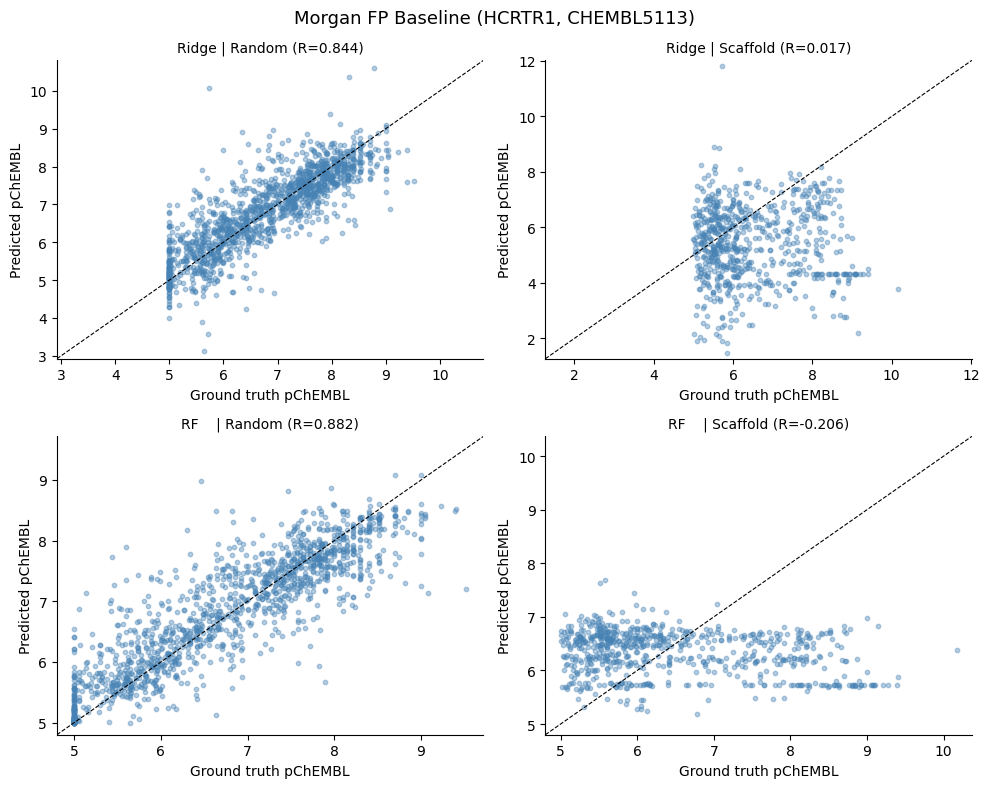

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
fig.suptitle('Morgan FP Baseline (HCRTR1, CHEMBL5113)', fontsize=13)

pairs = [
    (axes[0, 0], y_test_rnd,      ridge_preds_rnd, f'Ridge | Random (R={ridge_r_rnd:.3f})'),
    (axes[0, 1], y_test_scaffold,  ridge_preds_scf, f'Ridge | Scaffold (R={ridge_r_scf:.3f})'),
    (axes[1, 0], y_test_rnd,      rf_preds_rnd,    f'RF    | Random (R={rf_r_rnd:.3f})'),
    (axes[1, 1], y_test_scaffold,  rf_preds_scf,    f'RF    | Scaffold (R={rf_r_scf:.3f})'),
]

for ax, y_true, y_pred, title in pairs:
    ax.scatter(y_true, y_pred, alpha=0.4, s=10, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()) - 0.2, max(y_true.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'k--', linewidth=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Ground truth pChEMBL')
    ax.set_ylabel('Predicted pChEMBL')
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.savefig('morgan_fp_baseline_scatter.png', dpi=150)
plt.show()

Results summary

In [10]:
results = pd.DataFrame([
    {'Model': 'Morgan FP + Ridge',  'Split': 'Random 80/20', 'Pearson R': round(ridge_r_rnd, 3), 'RMSE': round(ridge_rmse_rnd, 3)},
    {'Model': 'Morgan FP + Ridge',  'Split': 'Scaffold',     'Pearson R': round(ridge_r_scf, 3), 'RMSE': round(ridge_rmse_scf, 3)},
    {'Model': 'Morgan FP + RF',     'Split': 'Random 80/20', 'Pearson R': round(rf_r_rnd, 3),    'RMSE': round(rf_rmse_rnd, 3)},
    {'Model': 'Morgan FP + RF',     'Split': 'Scaffold',     'Pearson R': round(rf_r_scf, 3),    'RMSE': round(rf_rmse_scf, 3)},
])
print(results.to_string(index=False))

            Model        Split  Pearson R  RMSE
Morgan FP + Ridge Random 80/20      0.844 0.615
Morgan FP + Ridge     Scaffold      0.017 2.039
   Morgan FP + RF Random 80/20      0.882 0.527
   Morgan FP + RF     Scaffold     -0.206 1.293
